In [127]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import scipy.io as spio
import scipy.signal as signal

# Projeto 2 - Sinais e Sistemas em Tempo Discreto - 2024/01
# Identificação
## Nome: Leonardo Pereira Côrtes
## Matrícula: 200030582

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [128]:
#Código das funções utilizadas.

# Questão 1

Um sistema de aquisição de dados de eletrocardiograma foi ligado de forma equivocada perto demais da rede elétrica. Assim, a interferência da rede elétrica (a 60 Hz) aparece de forma marcante no sinal adquirido. O seu objetivo é projetar um filtro digital para eliminar totalmente o ruído em 60Hz. A frequência de amostragem do sistema é: 

$$ f_a = 500~Hz $$ 

Siga as questões abaixo.

## Questão 1a (0.5  pontos)

Projete o filtro em questão utilizando a colocação de pólos e zeros no plano z. Desenhe o diagrama de pólos e zeros do filtro projetado, indicando quais pólos e zeros foram indicados e o porquê destes pólos/zeros terem sido escolhidos. Você pode inserir o seu projeto como uma imagem escaneada abaixo.

<img src="./Q1a.jpg" width="630" height="800" />

In [129]:
#Resposta da questão 1a

## Questão 1b (0.5 pontos)

A partir do diagrama desenvolvido na questão anterior, escreva a função de transferência do filtro H(z) e a equação de diferenças do sistema que realiza o filtro. Você pode inserir sua resposta como uma imagem escaneada abaixo.

<img src="./Q1b.jpg" width="750" height="475" />

In [130]:
#Resposta da questão 1b

## Questão 1c (1  ponto)

Plote a **resposta em frequência** do filtro projetado (magnitude e fase). 

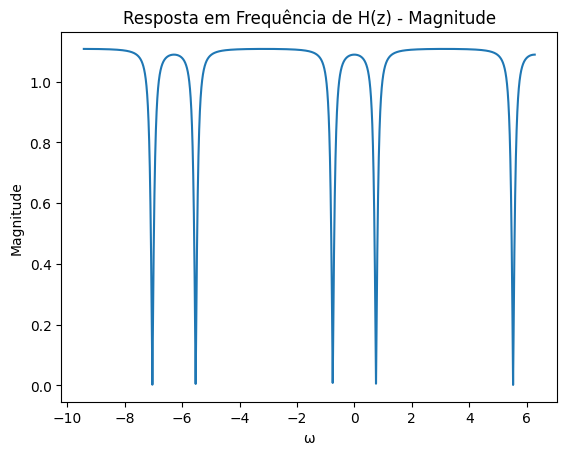

Text(0, 0.5, 'Fase (Graus)')

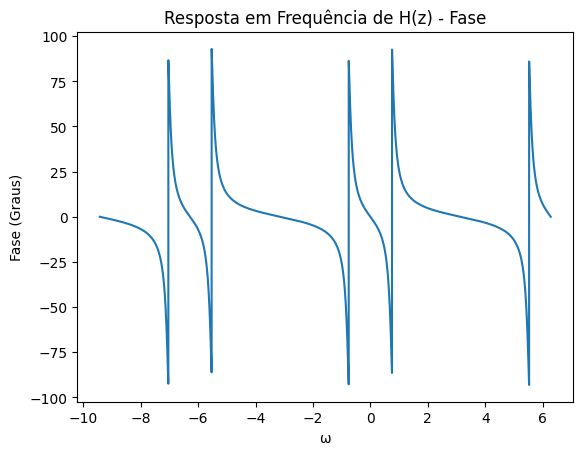

In [131]:
#Resposta da questão 1c
b0 = 1
b1 = -1.458
b2 = 1
a0 = 1
a1 = -1.3122
a2 = 0.81

w = np.linspace(-3 * np.pi, 2 * np.pi, 10000)
z = np.exp(1j * w)

h = (b0*(z**2) + b1*z + b2) / (a0*(z**2) + a1*z + a2)
h_fase_graus = np.angle(h, deg=True)

plt.plot(w, abs(h))
plt.title('Resposta em Frequência de H(z) - Magnitude')
plt.xlabel('ω')
plt.ylabel('Magnitude')
plt.show()

plt.plot(w, h_fase_graus)
plt.title('Resposta em Frequência de H(z) - Fase')
plt.xlabel('ω')
plt.ylabel('Fase (Graus)')

## Questão 1d (0.5  pontos)

Carregue o sinal de ECG "noisy_ecg_data.mat" e aplique o filtro projetado neste sinal. Plote o sinal antes da filtragem (x[n]) e o sinal após a filtragem (y[n]).

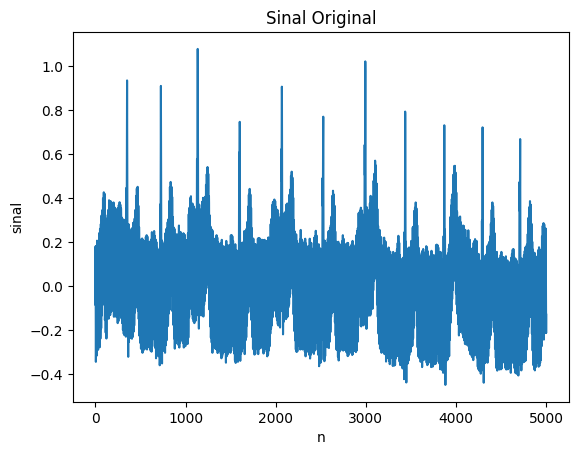

Text(0, 0.5, 'sinal')

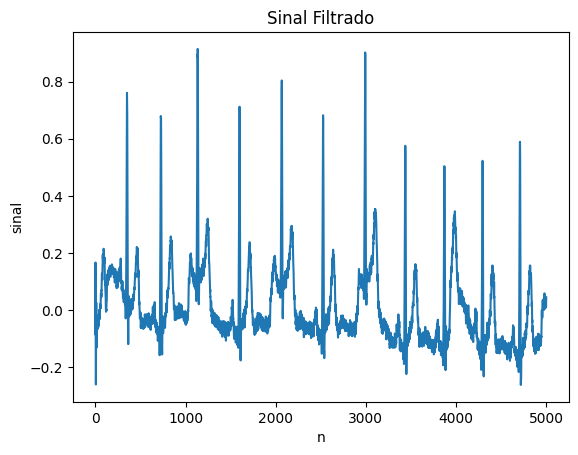

In [132]:
#Resposta da questão 1d
sinal = sp.io.loadmat('noisy_ecg_data.mat')['noisy_ecg'].ravel()

b0 = 1
b1 = -1.458
b2 = 1
a0 = 1
a1 = -1.3122
a2 = 0.81

sinal_filtrado = np.zeros_like(sinal)

for n in range(len(sinal)):
    if n >= 2:
        sinal_filtrado[n] = b0*sinal[n] + b1*sinal[n-1] + b2*sinal[n-2] - a1*sinal_filtrado[n-1] - a2*sinal_filtrado[n-2]
    elif n == 1:
        sinal_filtrado[n] = b0*sinal[n] + b1*sinal[n-1] - a1*sinal_filtrado[n-1]
    else:
        sinal_filtrado[n] = b0*sinal[n]

plt.plot(sinal)
plt.title('Sinal Original')
plt.xlabel('n')
plt.ylabel('sinal')
plt.show()

plt.plot(sinal_filtrado)
plt.title('Sinal Filtrado')
plt.xlabel('n')
plt.ylabel('sinal')

# Questão 2

Ainda no sistema de aquisição de dados de eletrocardiograma, mais tarde foi verificado que, mesmo depois de resolvido o problema da interferência da rede elétrica (i.e., o sinal não tem um ruído específico em 60Hz), o sinal adquirido tinha bastante ruído de alta frequência (acima de 35Hz). O objetivo desta questão é projetar um filtro digital para atenuar as frequências acima de 35Hz. A frequêencia de amostragem do sistema é:

$$ f_a = 500~Hz $$

Siga as questões abaixo.

## Questão 2a (0.5  pontos)

Projete o filtro em questão utilizando a colocação de pólos e zeros no plano z. Desenhe o diagrama de pólos e zeros do filtro projetado, indicando quais pólos e zeros foram indicados e o porquê destes pólos/zeros terem sido escolhidos. Você pode inserir o seu projeto como uma imagem escaneada abaixo.

<img src="./Q2a.jpg" width="725" height="760" />

In [133]:
#Resposta da questão 2a

## Questão 2b (0.5 pontos)

A partir do diagrama desenvolvido na questão anterior, escreva a função de transferência do filtro H(z) e a equação de diferenças do sistema que realiza o filtro. Você pode inserir sua resposta como uma imagem escaneada abaixo.

<img src="./Q2b.jpg" width="725" height="525" />

In [134]:
#Resposta da questão 2b

## Questão 2c (1  ponto)

Plote a **resposta em frequência** do filtro projetado (magnitude e fase). 

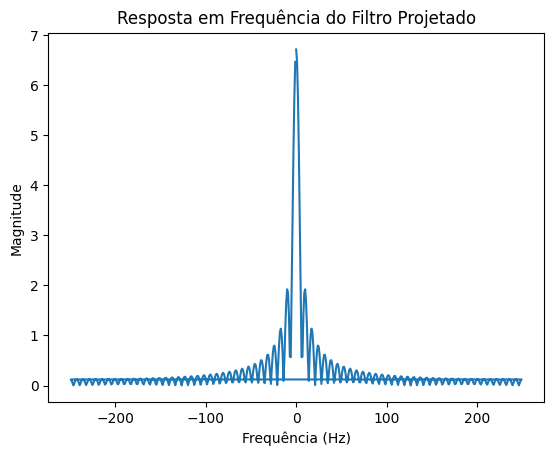

Text(0, 0.5, 'Fase (rad)')

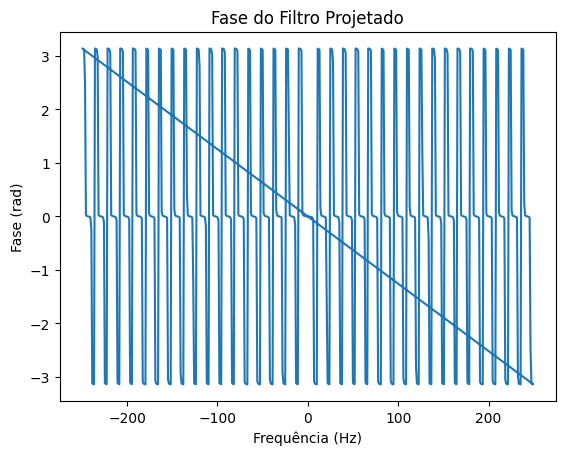

In [135]:
#Resposta da questão 2c
fs = 500
fc = 35
n_pontos = 501

freq = np.fft.fftfreq(n_pontos, d=1/fs)
filtro_ideal = np.where(np.abs(freq) <= fc, 1, 0)
resposta_filtro = filtro_ideal * np.hamming(n_pontos)
resposta_frequencia = np.fft.fft(resposta_filtro)

plt.plot(freq, np.abs(resposta_frequencia))
plt.title('Resposta em Frequência do Filtro Projetado')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.show()

plt.plot(freq, np.angle(resposta_frequencia))
plt.title('Fase do Filtro Projetado')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (rad)')

## Questão 2d (0.5  pontos)

Carregue o sinal de ECG "noisy_ecg_data_2.mat" e aplique o filtro projetado neste sinal. Plote o sinal antes da filtragem (x[n]) e o sinal após a filtragem (y[n]).

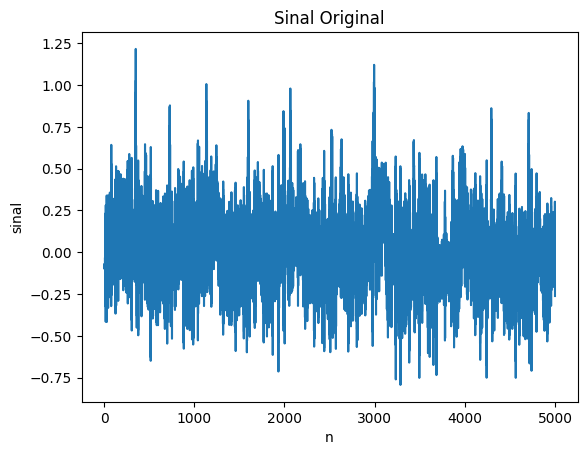

Text(0, 0.5, 'sinal')

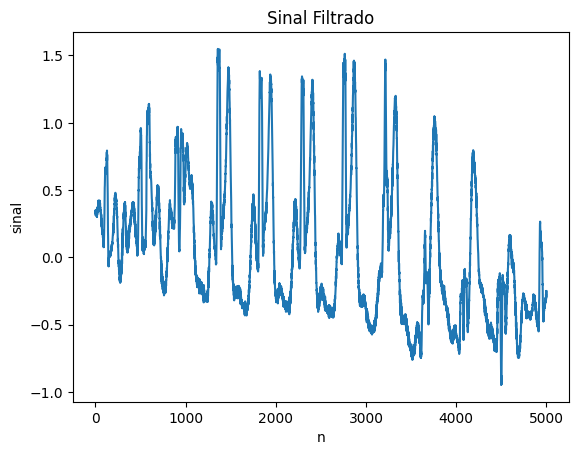

In [136]:
#Resposta da questão 2d
sinal = sp.io.loadmat('noisy_ecg_data_2.mat')['noisy_ecg2'].ravel()

fs = 500
fc = 35
n_pontos = 501

freq = np.fft.fftfreq(n_pontos, d=1/fs)
filtro_ideal = np.where(np.abs(freq) <= fc, 1, 0)
resposta_filtro = filtro_ideal * np.hamming(n_pontos)
sinal_filtrado = np.convolve(sinal, resposta_filtro, mode='same')

plt.plot(sinal)
plt.title('Sinal Original')
plt.xlabel('n')
plt.ylabel('sinal')
plt.show()

plt.plot(sinal_filtrado)
plt.title('Sinal Filtrado')
plt.xlabel('n')
plt.ylabel('sinal')

# Questão 3

Considere o filtro analógico:

$$ H_a \left(s\right) = \frac{\omega_c}{\omega_c + s}$$

E considere o valor:

$$\omega_c = 10^3 $$

## Questão 3a (1  ponto)

Projete uma aproximação digital para este filtro com critério de 10%. Indique a taxa de amostragem calculada para esta aproximação (T1) e compare a resposta em frequência do filtro projetado H1() com a resposta em frequência do filtro analógic Ha(). Plote as frequências até ao menos:

$$ \omega = 10^5 \pi $$

Taxa de amostragem T1: 0.01


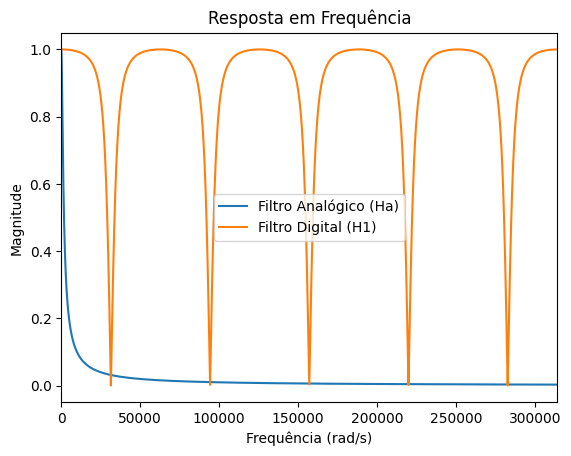

In [137]:
#Resposta da questão 3a
wc = 1e3
eps = 0.1 # Critério de aproximação (10%)
T1 = 1/(wc * eps)
w = np.linspace(0,1e5 * np.pi, 10000) # Frequências o plot

Ha = 1/(1 + 1j * w / wc)
b, a = signal.bilinear([1], [1 / wc, 1], fs=1 / T1)
w_d, H1 = signal.freqz(b, a, worN=w)

plt.plot(w, abs(Ha), label='Filtro Analógico (Ha)')
plt.plot(w, abs(H1), label='Filtro Digital (H1)')
plt.title('Resposta em Frequência')
plt.xlabel('Frequência (rad/s)')
plt.ylabel('Magnitude')
plt.xlim(0, 1e5 * np.pi)  # Limitando o eixo x
plt.legend()

print('Taxa de amostragem T1:', T1)

## Questão 3b (1  ponto)

Projete uma aproximação digital para este filtro com critério de 1%. Indique a taxa de amostragem calculada para esta aproximação (T2) e compare a resposta em frequência do filtro projetado H2() com a resposta em frequência do filtro analógic Ha(). Plote as frequências até ao menos:

$$ \omega = 10^5 \pi $$

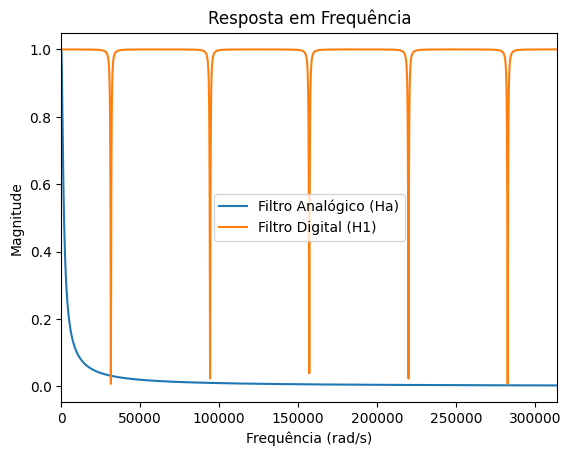

Taxa de amostragem T2: 0.1


In [138]:
#Resposta da questão 3b
wc = 1e3
eps = 0.01 # Critério de aproximação (1%)
T2 = 1/(wc * eps)
w = np.linspace(0, 1e5 * np.pi, 10000)

Ha = 1/(1 + 1j * w / wc)
b, a = signal.bilinear([1], [1 / wc, 1], fs=1 / T2)
w_d, H1 = signal.freqz(b, a, worN=w)

plt.plot(w, abs(Ha), label='Filtro Analógico (Ha)')
plt.plot(w, abs(H1), label='Filtro Digital (H1)')
plt.title('Resposta em Frequência')
plt.xlabel('Frequência (rad/s)')
plt.ylabel('Magnitude')
plt.xlim(0, 1e5 * np.pi)
plt.legend()
plt.show()

print('Taxa de amostragem T2:', T2)

## Questão 3c (1 ponto)

Calcule a resposta ao impulso ha(t) do filtro analógico Ha(s), bem como as respostas ao impulso h1[n] e h2[n] dos filtros projetados H1(z) e H2(z). **Plote** as respostas ao impulso na mesma escala.

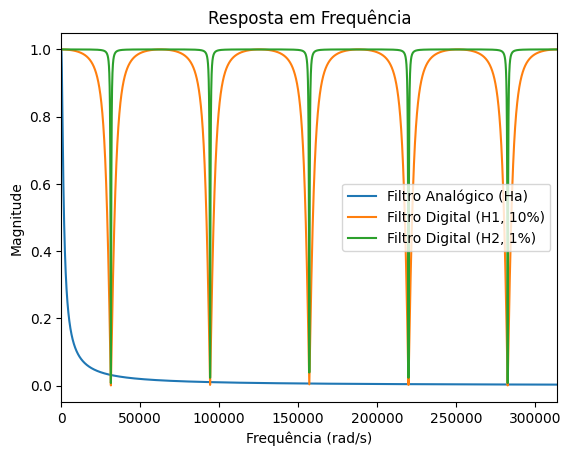

Taxa de amostragem T1 (10%): 0.01
Taxa de amostragem T2 (1%): 0.1


In [139]:
#Resposta da questão 3c
wc = 1e3
eps1 = 0.1 # Critério de aproximação (10%)
T1 = 1/(wc * eps1)
w = np.linspace(0, 1e5 * np.pi, 10000)

Ha1 = 1/(1 + 1j * w / wc)
b1, a1 = signal.bilinear([1], [1 / wc, 1], fs=1 / T1)
w_d1, H1 = signal.freqz(b1, a1, worN=w)

plt.plot(w, abs(Ha1), label='Filtro Analógico (Ha)')
plt.plot(w, abs(H1), label='Filtro Digital (H1, 10%)')

eps2 = 0.01 # Critério de aproximação (1%)
T2 = 1 / (wc * eps2)
b2, a2 = signal.bilinear([1], [1 / wc, 1], fs=1 / T2)
w_d2, H2 = signal.freqz(b2, a2, worN=w)

plt.plot(w, abs(H2), label='Filtro Digital (H2, 1%)')

plt.title('Resposta em Frequência')
plt.xlabel('Frequência (rad/s)')
plt.ylabel('Magnitude')
plt.xlim(0, 1e5 * np.pi)
plt.legend()
plt.show()

print('Taxa de amostragem T1 (10%):', T1)
print('Taxa de amostragem T2 (1%):', T2)

## Questão 3d (2 pontos)

Considere o sinal:
$$ x\left(t\right) = e^{- \lambda t} u\left(t\right)$$

com

$$\lambda = 500 $$

Calcule a resposta teórica do filtro analógico, y(t), bem como a resposta do filtro digital H1(z) ao sinal amostrado com taxa T1 (x1[n]) e a resposta do filtro digital H2(z) ao sinal amostrado com taxa T2 (x2[n]). **Plote**, na mesma escala, o sinal y(t) e as aproximações y1[n] e y2[n]. 

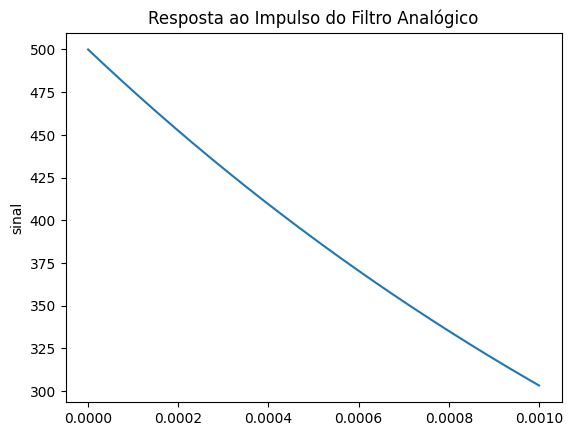

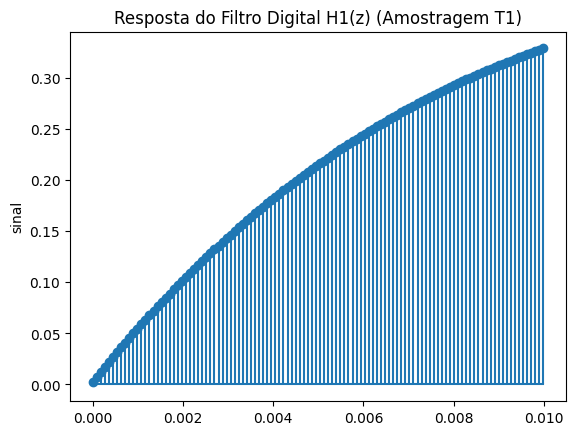

Text(0.5, 1.0, 'Resposta do Filtro Digital H2(z) (Amostragem T2)')

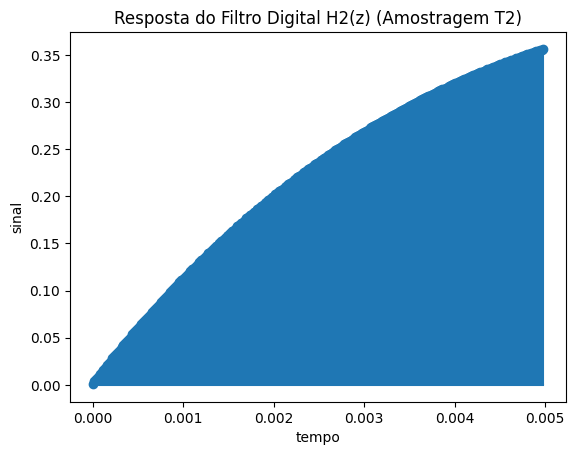

In [140]:
#Resposta da questão 3d
valor_lambda = 500
T1 = 1e-5
T2 = 5e-6

t = np.linspace(0, 1e-3, 1000)
y_t = signal.impulse(([1], [1 / valor_lambda, 1]), T=t)[1]

b1, a1 = signal.bilinear([1], [1 / valor_lambda, 1], fs=1 / T1)
b2, a2 = signal.bilinear([1], [1 / valor_lambda, 1], fs=1 / T2)

x = np.exp(-valor_lambda * t) * (t >= 0)

n1 = np.arange(0, len(x), int(T1/t[1]))
n2 = np.arange(0, len(x), int(T2/t[1]))

y1_n = signal.lfilter(b1, a1, x[n1])
y2_n = signal.lfilter(b2, a2, x[n2])

plt.plot(t, y_t)
plt.ylabel('sinal')
plt.title('Resposta ao Impulso do Filtro Analógico')
plt.show()

plt.stem(n1 * T1, y1_n, linefmt='C0', markerfmt='C0o', basefmt='C0')
plt.ylabel('sinal')
plt.title('Resposta do Filtro Digital H1(z) (Amostragem T1)')
plt.show()

plt.stem(n2 * T2, y2_n, linefmt='C0', markerfmt='C0o', basefmt='C0')
plt.xlabel('tempo')
plt.ylabel('sinal')
plt.title('Resposta do Filtro Digital H2(z) (Amostragem T2)')
